In [50]:
import cftime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
from scipy import interpolate
from scipy import io
from scipy import ndimage
import xarray as xr
import cmocean 

plt.rcParams['image.origin'] = 'lower'


%load_ext autoreload
%autoreload 2
%matplotlib inline



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
mission_df = pd.read_csv('../../data/mission_df.csv')
ds = xr.load_dataset('../../data/FRF_geomorphology_DEMs_surveyDEM_20211021.nc')
ds

<xarray.Dataset> Size: 94kB
Dimensions:                (time: 1, xFRF: 76, yFRF: 51, project: 16)
Coordinates:
  * time                   (time) datetime64[ns] 8B 2021-10-21
  * xFRF                   (xFRF) float64 608B 50.0 62.0 74.0 ... 938.0 950.0
  * yFRF                   (yFRF) float64 408B -100.0 -76.0 ... 1.1e+03
    project                (time, project) object 128B b'D' b'D' ... b'D' b'D'
Data variables:
    elevation              (time, yFRF, xFRF) float64 31kB 2.162 ... -9.155
    latitude               (yFRF, xFRF) float64 31kB 36.18 36.18 ... 36.19 36.19
    longitude              (yFRF, xFRF) float64 31kB -75.75 -75.75 ... -75.74
    surveyNumber           (time) float64 8B 1.228e+03
    surveyVehicle          (time) float32 4B 1.0
    surveyInstrumentation  (time) float32 4B 3.0
    versionDate            (time) datetime64[ns] 8B 2021-10-28
Attributes: (12/46)
    origin:                          USACE/CHL/COAB
    Metadata_Conventions:            Unidata Dataset Discovery v1.0, CF-1.6
    format_version:                  v1.0
    contact_info:                    USACE/CHL/COAB
    geospatial_lat_units:            degrees_north
    cross_shore_angle_description:   cross shore angle at the USACE FRF site ...
    ...                              ...
    geospatial_vertical_positive:    up
    creator_url:                     http://frf.usace.army.mil
    geospatial_vertical_units:       m
    history:                         stuff
    date_created:                    2021-10-28
    date_issued:                     2021-10-28

In [52]:
bathy_x_grid, bathy_y_grid = np.meshgrid(ds.xFRF, ds.yFRF)

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_54592/1208158693.py:6: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(*mgrid, ds.elevation.isel(time=0),


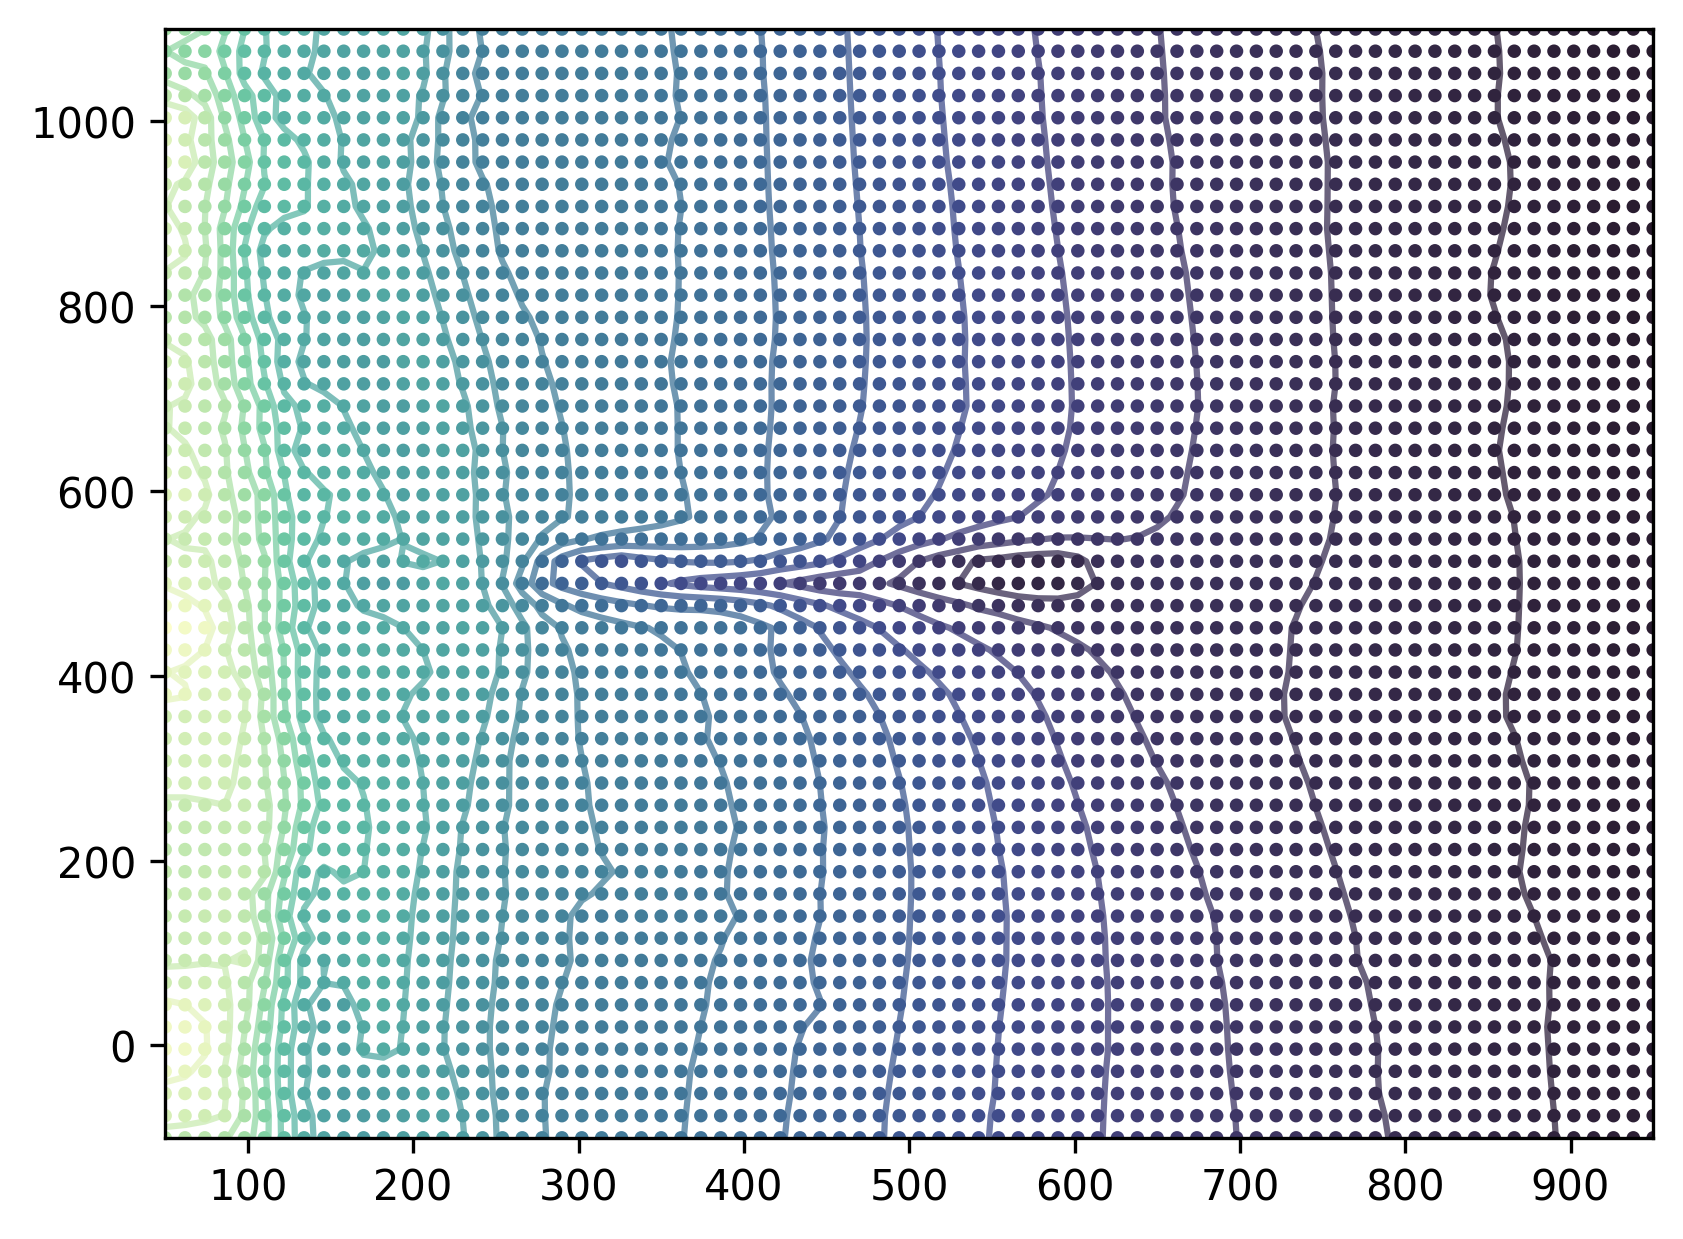

In [53]:
fig, ax = plt.subplots(dpi=300)
mgrid = np.meshgrid(ds.xFRF, ds.yFRF)
ax.scatter(*mgrid, c=ds.elevation, 
           s=5, vmin=ds.elevation.min(), vmax=ds.elevation.max(),
           cmap=cmocean.cm.deep_r, label='DEM Survey')
ax.contour(*mgrid, ds.elevation.isel(time=0), 
           levels=np.linspace(ds.elevation.min(), ds.elevation.max(), 21), 
           cmap=cmocean.cm.deep_r, zorder=-1, alpha=0.75, linewidth=10)


Text(0.5, 1.0, 'Slope Y (alongshore)')

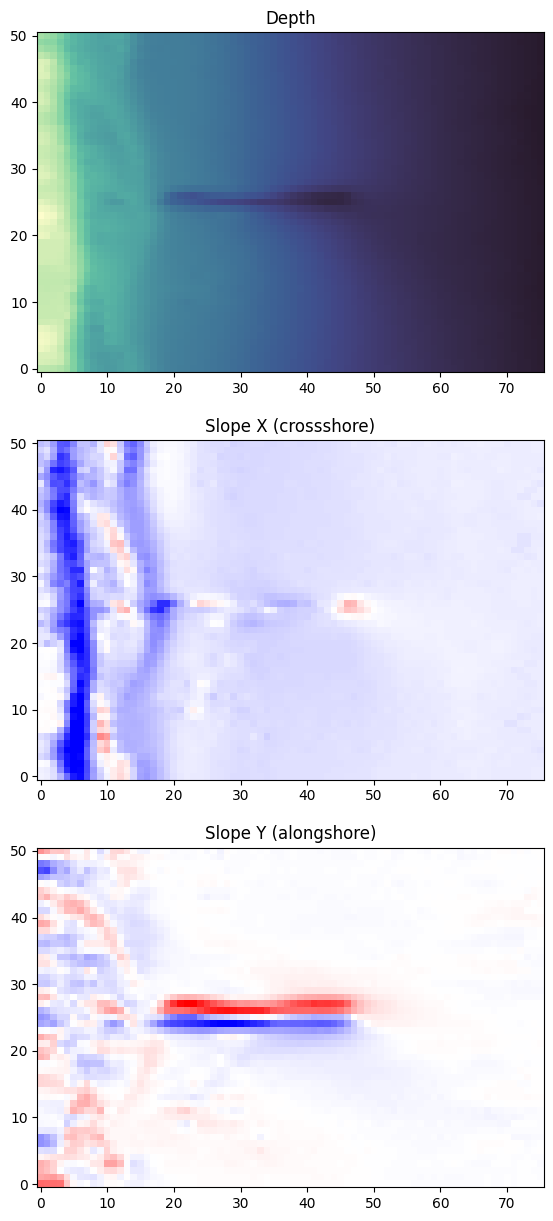

In [54]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
axs[0].imshow(ds.elevation.isel(time=0), cmap=cmocean.cm.deep_r)
axs[0].set_title('Depth')
axs[1].imshow(np.gradient(ds.elevation.isel(time=0))[1], vmin=-1, vmax=1, cmap='bwr')
axs[1].set_title('Slope X (crossshore)')
axs[2].imshow(np.gradient(ds.elevation.isel(time=0))[0], vmin=-1, vmax=1, cmap='bwr')
axs[2].set_title('Slope Y (alongshore)')


In [55]:
# There are a lot of dates available here for the whole month of october 10/6-10/23 continuous
# https://chlthredds.erdc.dren.mil/thredds/catalog/frf/geomorphology/elevationTransects/survey/data/catalog.html
trans = xr.open_dataset('../../data/FRF_geomorphology_elevationTransects_survey_20211008.nc')

In [56]:
trans_interp = interpolate.griddata(
    np.array((trans.xFRF, trans.yFRF)).reshape(2, -1).T,
    trans.elevation,
    np.array(mgrid).reshape(2, -1).T,
    method='linear', fill_value=np.nan)


Text(0.5, 1.0, 'Slope Y (alongshore)')

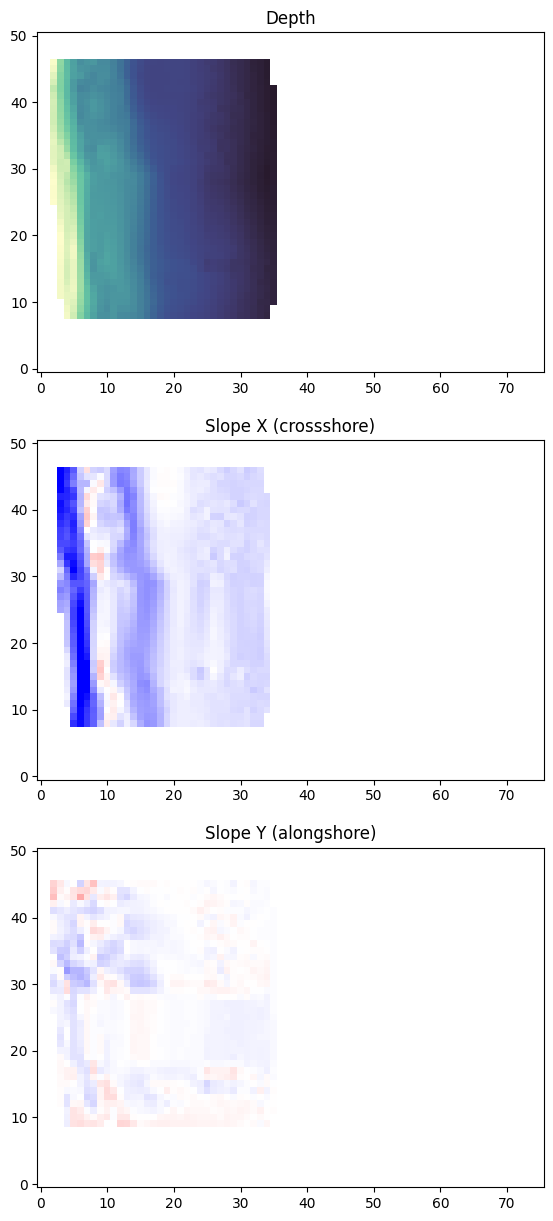

In [57]:
img = trans_interp.reshape(mgrid[0].shape)
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
axs[0].imshow(img, cmap=cmocean.cm.deep_r)
axs[0].set_title('Depth')
axs[1].imshow(np.gradient(img)[1], vmin=-1, vmax=1, cmap='bwr')
axs[1].set_title('Slope X (crossshore)')
axs[2].imshow(np.gradient(img)[0], vmin=-1, vmax=1, cmap='bwr')
axs[2].set_title('Slope Y (alongshore)')

901
1001
(2002, 901)
Values to put in SWAN input file 900 1000


Text(0.5, 0.98, 'Bathy Meshgrid')

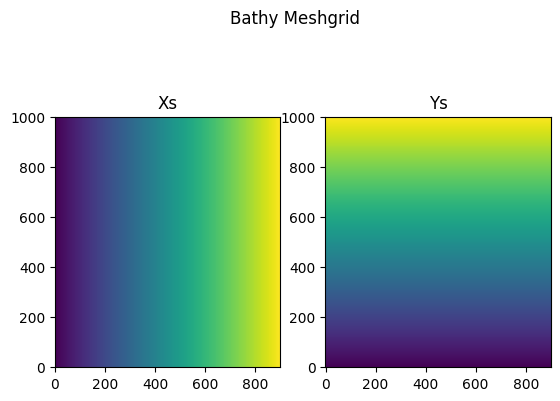

In [58]:
# Define grid cell edge size
x_cgrid_size = 1 # units are meters
y_cgrid_size = 1 # units are meters

# Define grid edges
x_cgrid_min = 50
x_cgrid_max = 950
y_cgrid_min = 0
y_cgrid_max = 1000

num_x_points = int((x_cgrid_max - x_cgrid_min) / x_cgrid_size)+1
print(num_x_points)
num_y_points = int((y_cgrid_max - y_cgrid_min) / y_cgrid_size)+1
print(num_y_points)

x_cgrid, y_cgrid = np.meshgrid(np.linspace(x_cgrid_min, x_cgrid_max, num_x_points),
                               np.linspace(y_cgrid_min, y_cgrid_max, num_y_points))

swan_cgrid = np.concatenate((x_cgrid, y_cgrid), axis=0)
print(swan_cgrid.shape)


print(f'Values to put in SWAN input file {num_x_points-1} {num_y_points-1}')

fig, axs = plt.subplots(1, 2)
axs[0].imshow(x_cgrid)
axs[0].set_title('Xs')
axs[1].imshow(y_cgrid)
axs[1].set_title('Ys')
fig.suptitle('Bathy Meshgrid')

In [59]:
elevation_regridded = interpolate.interpn(
    (ds.xFRF, ds.yFRF), 
    ds.elevation.isel(time=0).values.T, 
    (x_cgrid, y_cgrid), method='linear', fill_value=0)


Text(0.5, 1.0, 'Slope Y (alongshore)')

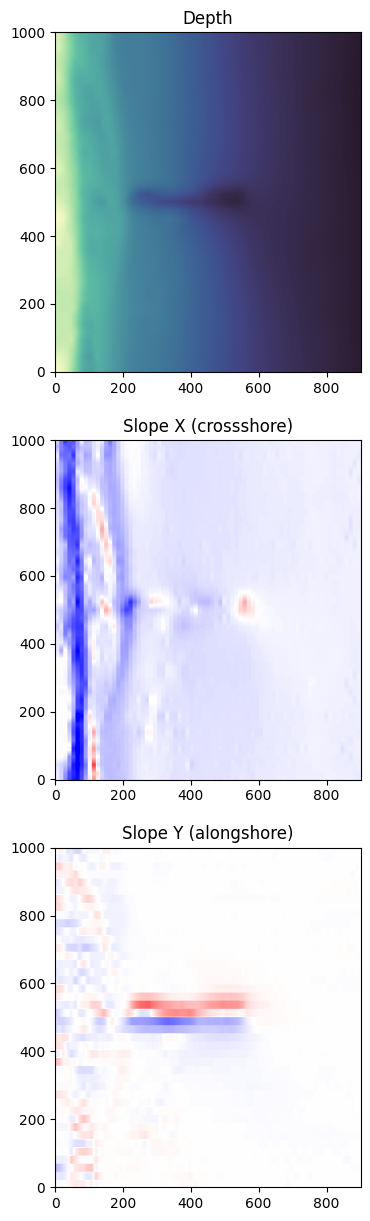

In [60]:
img = elevation_regridded
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
axs[0].imshow(img, cmap=cmocean.cm.deep_r)
axs[0].set_title('Depth')
scale=0.1
axs[1].imshow(np.gradient(img)[1], vmin=-scale, vmax=scale, cmap='bwr')
axs[1].set_title('Slope X (crossshore)')
axs[2].imshow(np.gradient(img)[0], vmin=-scale, vmax=scale, cmap='bwr')
axs[2].set_title('Slope Y (alongshore)')

Text(0.5, 1.0, 'Slope Y (alongshore)')

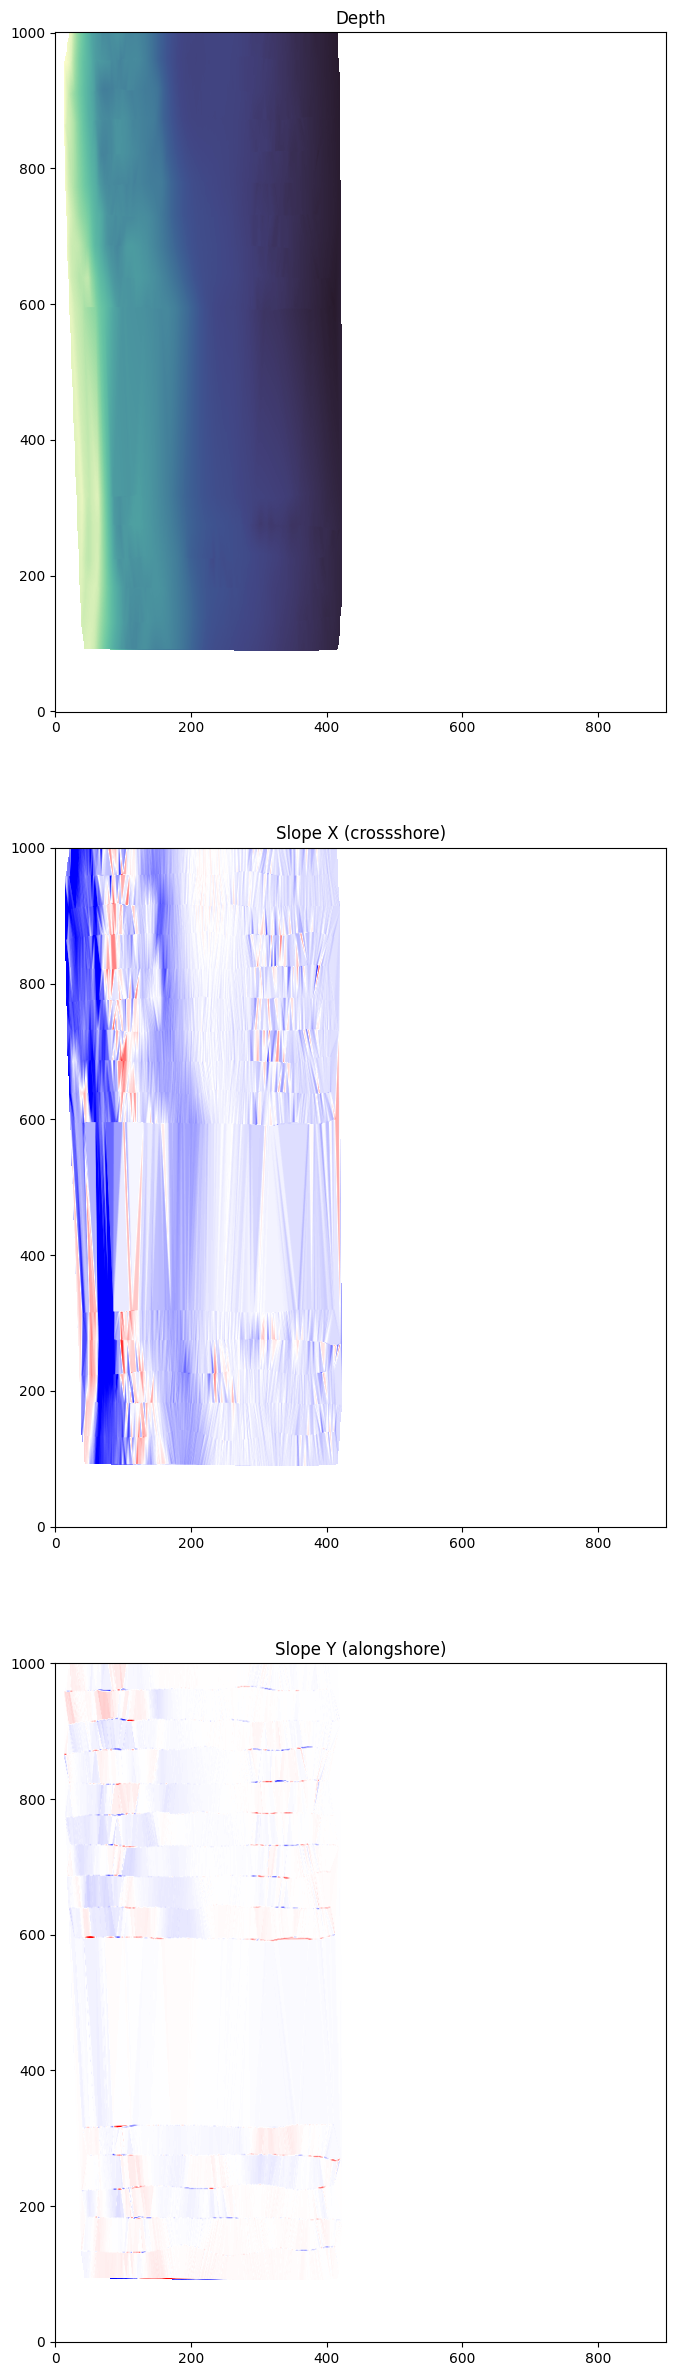

In [174]:
trans_interp = trans_interp = interpolate.griddata(
    (trans.xFRF, trans.yFRF),
    trans.elevation,
    np.array((x_cgrid, y_cgrid)).reshape(2, -1).T,
    method='linear', fill_value=np.nan).reshape(x_cgrid.shape)
img = trans_interp
fig, axs = plt.subplots(3, 1, figsize=(20, 30))
axs[0].imshow(img, cmap=cmocean.cm.deep_r)
axs[0].set_title('Depth')
scale=0.1
axs[1].imshow(np.gradient(img)[1], vmin=-scale, vmax=scale, cmap='bwr')
axs[1].set_title('Slope X (crossshore)')
axs[2].imshow(np.gradient(img)[0], vmin=-scale, vmax=scale, cmap='bwr')
axs[2].set_title('Slope Y (alongshore)')

In [61]:
trans_interp = interpolate.griddata(
    np.array(mgrid).reshape(2, -1).T,
    trans_interp,
    np.array((x_cgrid, y_cgrid)).reshape(2, -1).T,
    method='linear', fill_value=np.nan)


Text(0.5, 1.0, 'Slope Y (alongshore)')

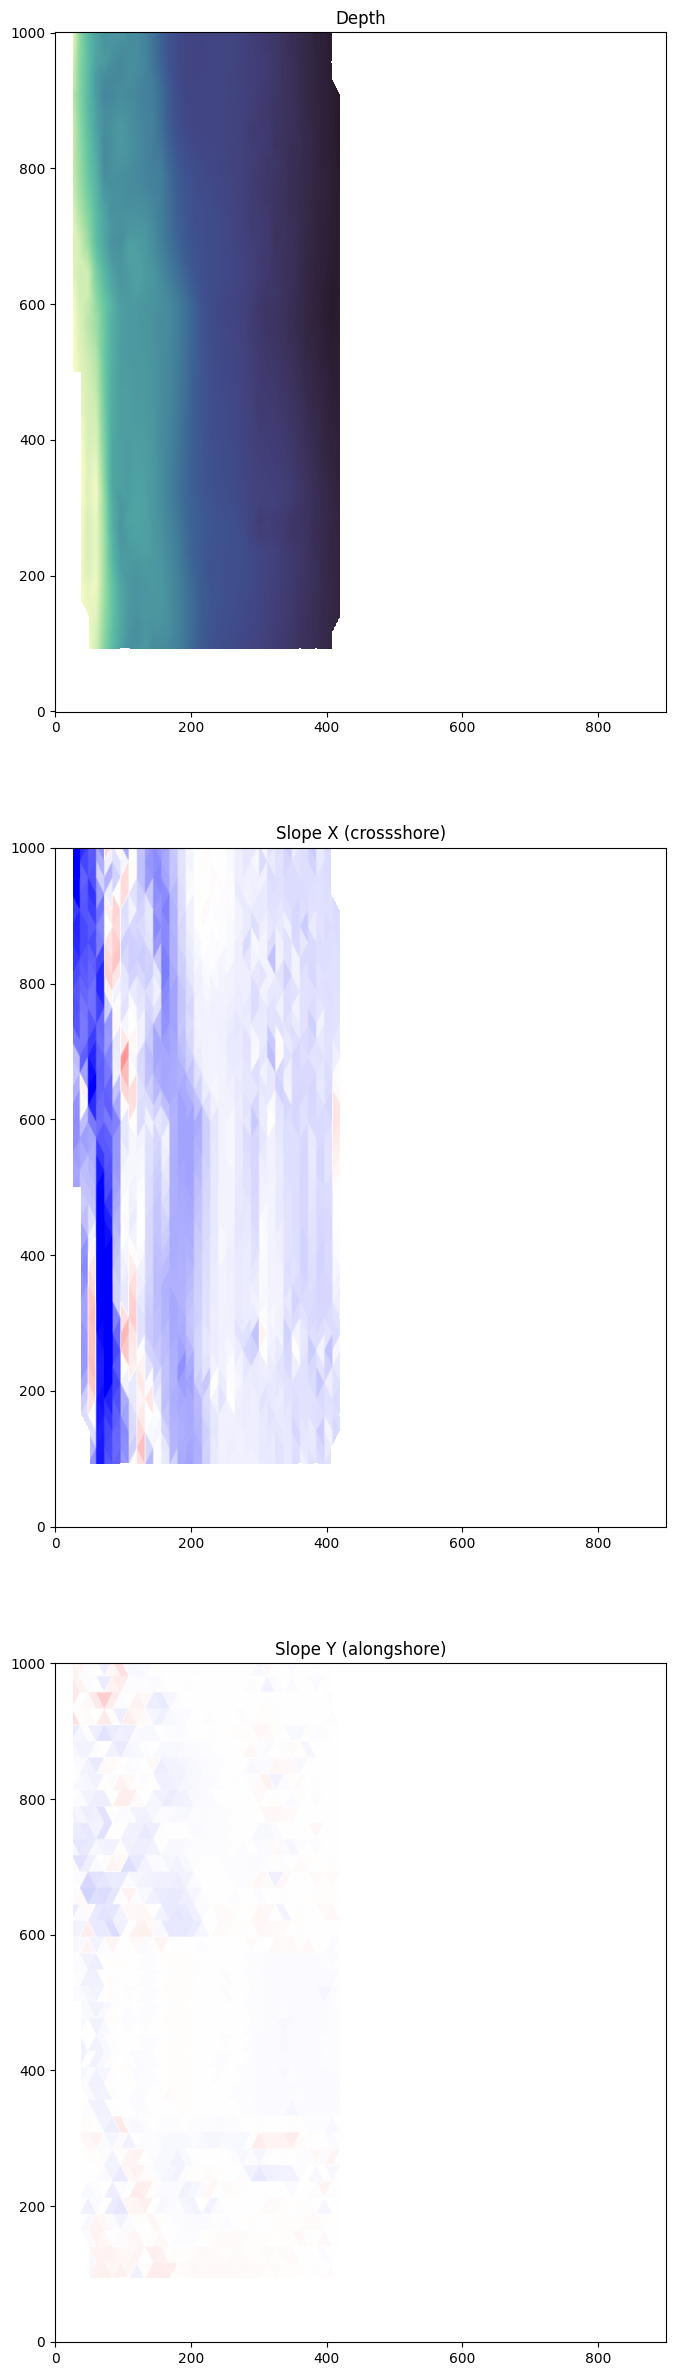

In [63]:
img = trans_interp.reshape(x_cgrid.shape)
fig, axs = plt.subplots(3, 1, figsize=(20, 30))
axs[0].imshow(img, cmap=cmocean.cm.deep_r)
axs[0].set_title('Depth')
scale=0.1
axs[1].imshow(np.gradient(img)[1], vmin=-scale, vmax=scale, cmap='bwr')
axs[1].set_title('Slope X (crossshore)')
axs[2].imshow(np.gradient(img)[0], vmin=-scale, vmax=scale, cmap='bwr')
axs[2].set_title('Slope Y (alongshore)')

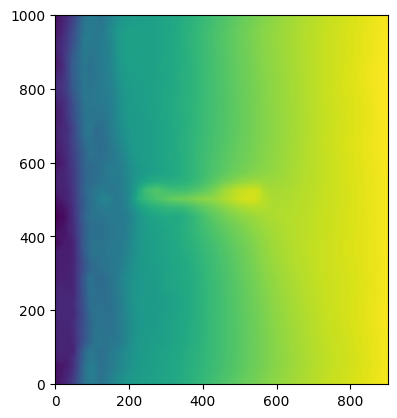

In [167]:
zgrid = trans_interp.copy().reshape(x_cgrid.shape)

# Fill missing data
zgrid[0:100,:] = elevation_regridded[0:100,:]
zgrid[85:115, :] = np.linspace(zgrid[85, :], zgrid[115, :], 30)


zgrid[300:600,:] = elevation_regridded[300:600,:]
zgrid[285:315, :] = np.linspace(zgrid[285, :], zgrid[315, :], 30)
zgrid[585:615, :] = np.linspace(zgrid[585, :], zgrid[615, :], 30)


zgrid[:,:65] = elevation_regridded[:, :65]
zgrid[:, 50:80] = np.linspace(zgrid[:, 50], zgrid[:, 80], 30).T
zgrid[:,400:] = elevation_regridded[:,400:]
zgrid[:, 385:415] = np.linspace(zgrid[:, 385], zgrid[:, 415], 30).T

# Interpolate for periodic boundary
interp_range = 50
zgrid[:interp_range, :] = np.linspace(
    (zgrid[-interp_range, :] + zgrid[interp_range, :])/2,
    zgrid[interp_range, :], interp_range)

zgrid[-interp_range:, :] = np.linspace(
    zgrid[-interp_range, :],
    (zgrid[-interp_range, :] + zgrid[interp_range, :])/2,
    interp_range)

# Invert

zgrid = -zgrid

plt.imshow(zgrid)

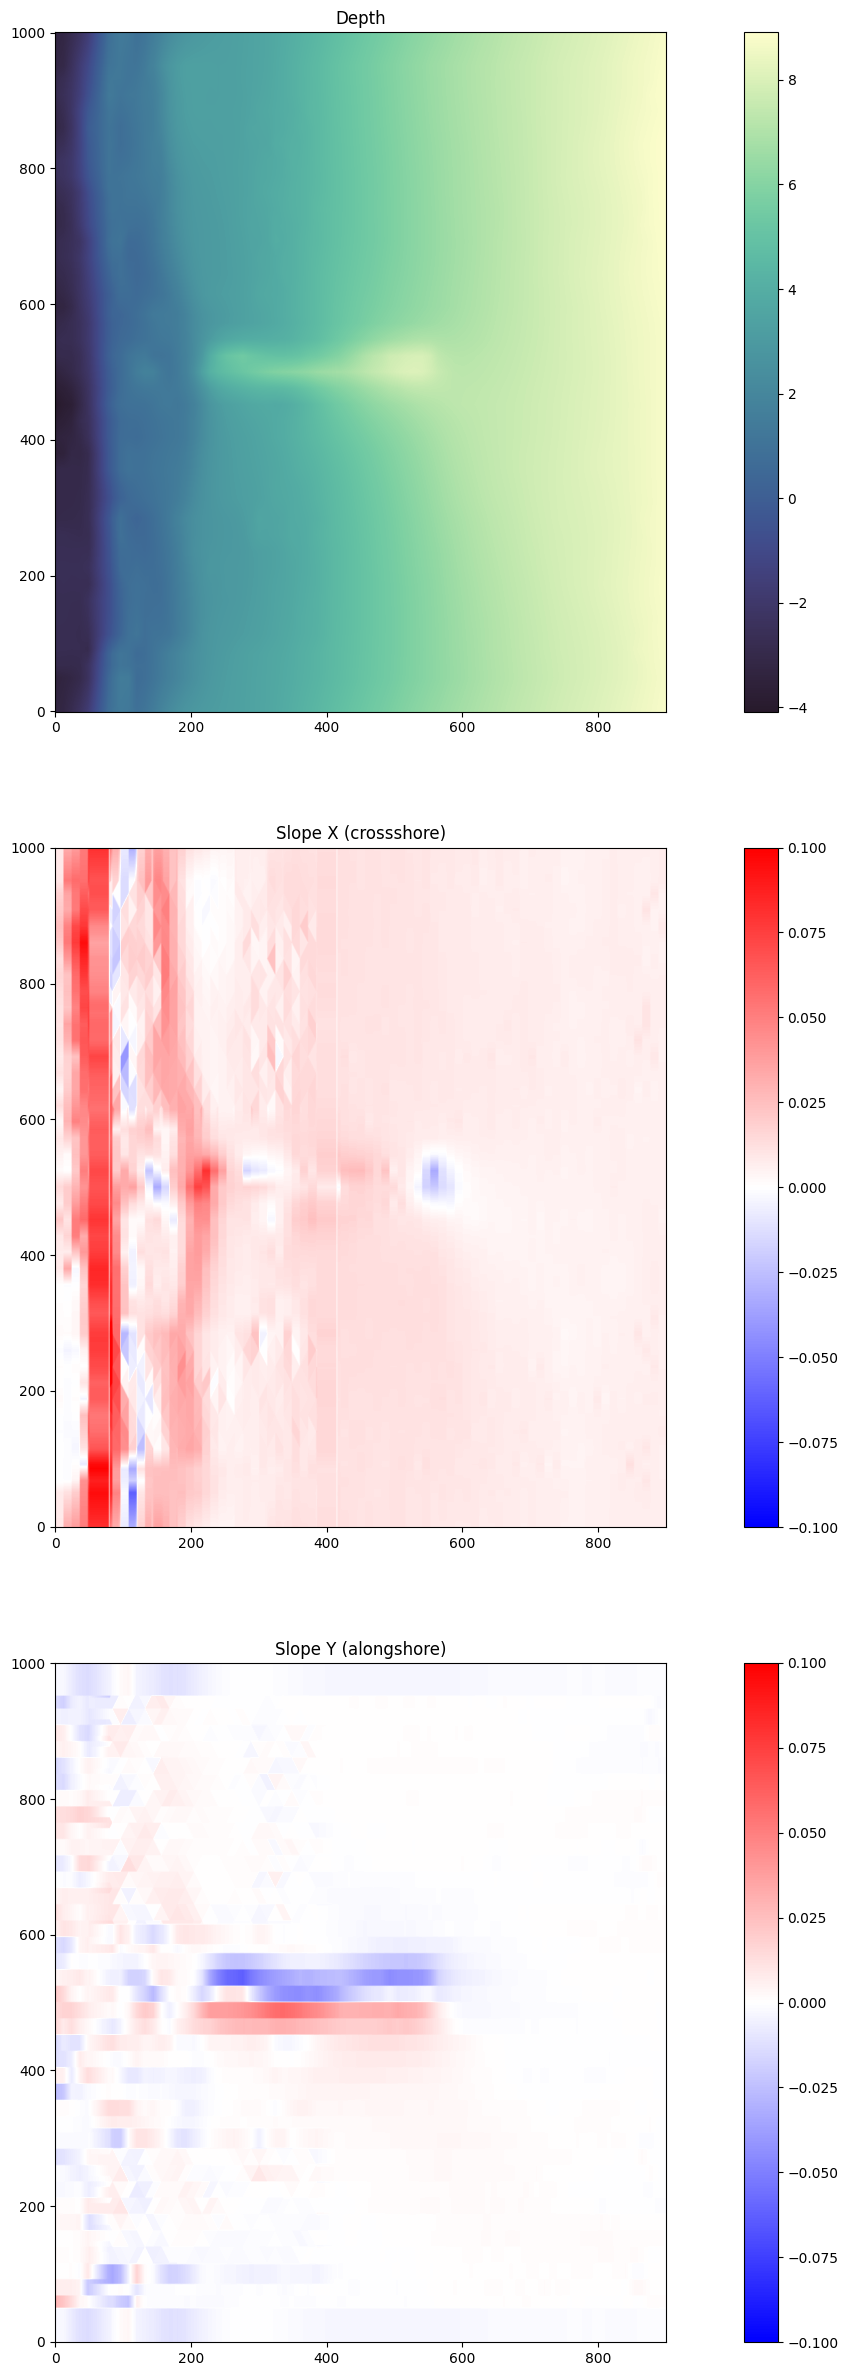

In [216]:
img = zgrid #ndimage.gaussian_filter(zgrid, (5, 1))
fig, axs = plt.subplots(3, 1, figsize=(20, 30))
im = axs[0].imshow(img, cmap=cmocean.cm.deep_r)
plt.colorbar(im , ax=axs[0])
axs[0].set_title('Depth')
scale=0.1
im = axs[1].imshow(np.gradient(img)[1], vmin=-scale, vmax=scale, cmap='bwr')
axs[1].set_title('Slope X (crossshore)')
axs[2].imshow(np.gradient(img)[0], vmin=-scale, vmax=scale, cmap='bwr')
axs[2].set_title('Slope Y (alongshore)')
plt.colorbar(im , ax=axs[1])
plt.colorbar(im , ax=axs[2])


In [181]:
roms_grid = xr.load_dataset('ocean_dunex_base_grd.nc')
roms_grid['h'].values = zgrid
roms_grid['hraw'].values = zgrid[np.newaxis, ...]
roms_grid.to_netcdf('ocean_dunex_base_smooth.nc')

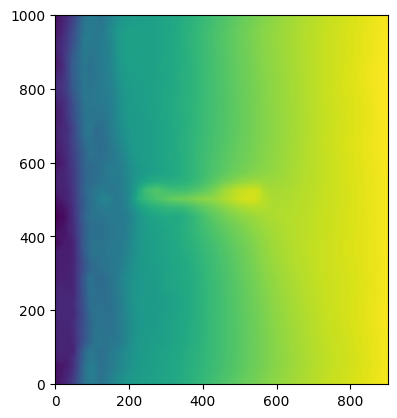

In [170]:
plt.imshow(zgrid)

In [182]:
# Write To ROMS NCDF 
roms_grid = xr.load_dataset('ocean_dunex_base_grd.nc')
roms_grid['h'].values = zgrid
roms_grid['hraw'].values = zgrid[np.newaxis, ...]
roms_grid.to_netcdf('ocean_dunex_base_smooth_nadv88.nc')

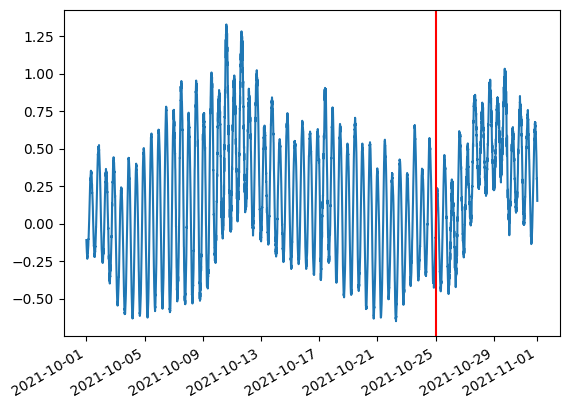

In [213]:
tides = xr.load_dataset('../../data/FRF-ocean_waterlevel_eopNoaaTide_202110.nc')
water_level = tides.waterLevel # relative NAVD88 just like bathymetry
fig = plt.figure()
plt.plot(water_level.time, water_level)
mission_id = 56
mission = xr.load_dataset(f'../../../data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission_{mission_id}.nc')
navd88_water_level = water_level.sel(time=mission.time.mean(), method='nearest').item()
navd88_water_level
plt.axvline(mission.time.mean().dt.date.item(), c='r')
# swandepth += navd88_water_level
fig.autofmt_xdate()
# plt.gca().get_xlim()


In [214]:
roms_grid['h'] += navd88_water_level
roms_grid['hraw'] += navd88_water_level
comp = dict(zlib=True, complevel=4)
encoding = {var: comp for var in roms_grid.data_vars}
roms_grid.to_netcdf(f'ocean_dunex_grd{mission_id}.nc', encoding=encoding)